# The OpenAI API

In this section we will cover the basics of using the OpenAI API, including:
- Chat Completions
- Streaming
- Vision input

The beauty of the OpenAI API is that is very simple to use.

In your environment you should have a file called `.env` with the following:

```bash
HPC_API_KEY="sk-proj-1234567890"
```

We will give you this key in the workshop. __The key will be deactivated after the workshop!__

You can then grab the key using python:


In [88]:
from openai import OpenAI
import dotenv
import os
from rich.console import Console

console = Console(width=88)

dotenv.load_dotenv()

client = OpenAI(
    base_url='https://llm.hpc.cam.ac.uk/v1/',
    api_key=os.getenv("HPC_API_KEY")
)

## Chat Completions

Calling a model is simple

In [89]:
system_prompt = "You are Matsuo Basho, the great Japanese haiku poet. When asked to provide a haiku, provide only the haiku. Don't overthink it."
user_query = "Can you give me a haiku about a Samurai cat."

response = client.chat.completions.create(
  model="moonshotai/Kimi-K3",
  messages=[
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_query},
  ],
)

print(response.choices[0].message.content)

Whiskers like sword steel—
the old cat dreams of battles
in the autumn rain


Purrfect.

The API offers a number of *_endpoints_* that allow you to interact with the available models. The main endpoint covered here is the `/chat/completions` endpoint, which allows you to interact with supported language models in a conversational manner.

Only two arguments are required for a basic request:

- `model: str` — The model to use. The currently available conversational models include:
  - `'Qwen/Qwen3.8-27B-FP8'`
  - `'Qwen/Qwen3.6-35B'`
  - `'moonshotai/Kimi-K3'`
  - `'zai-org/GLM-5.3'`

  Other models are also available for specialised tasks, such as:
  - `'zai-org/GLM-OCR'` — OCR and document/image text extraction.
  - `'Qwen/Qwen3-Embedding-4B'` — Text embeddings.
  - `'openai/Tongyi-MAI/Z-Image-Turbo'` — Image generation.
  - `'openai/Qwen/Qwen-Image-Edit-2511'` — Image editing.

  These specialised models may use different API endpoints or request formats and are not necessarily intended for `/chat/completions`.

- `messages: list` — A list of messages that provides the conversation context for the model. Each message is typically represented as:

```python
{"role": "<role>", "content": "<content>"}
```

The `<role>` can be one of the following:

- `'system'` — Instructions that guide the model's behaviour throughout the conversation. For example:

  *"You are a customer service assistant."*

- `'user'` — Input provided by the user. For example:

  *"How do I reset my password?"*

- `'assistant'` — A previous response generated by the assistant. Including assistant messages allows you to provide conversation history to the model. For example:

  *"To reset your password, visit the account page and select 'Forgot Password'."*

A complete message history might therefore look like:

```python
messages = [
    {"role": "system", "content": "You are a customer service assistant."},
    {"role": "user", "content": "How do I reset my password?"},
    {
        "role": "assistant",
        "content": "To reset your password, visit the account page and select 'Forgot Password'."
    }
]
```

A basic `/chat/completions` request could then use one of the available conversational models:

```python
response = client.chat.completions.create(
    model="Qwen/Qwen3.8-27B-FP8",
    messages=messages,
)
```

### Additional arguments
The `/chat/completions` endpoint also accepts a number of additional arguments that can be used to alter the response. These include (arguments are listed with their default values if applicable). See end of this notebook for a list.

### Available models

Here we have used model `Kimi-K3`, but there are a range of models available.

In [90]:
for model in client.models.list():
    print(model)

Model(id='Qwen/Qwen3.8-27B-FP8', created=1677610602, object='model', owned_by='openai')
Model(id='zai-org/GLM-OCR', created=1677610602, object='model', owned_by='openai')
Model(id='Qwen/Qwen3.6-35B', created=1677610602, object='model', owned_by='openai')
Model(id='moonshotai/Kimi-K3', created=1677610602, object='model', owned_by='openai')
Model(id='zai-org/GLM-5.3', created=1677610602, object='model', owned_by='openai')
Model(id='Qwen/Qwen3-Embedding-4B', created=1677610602, object='model', owned_by='openai')
Model(id='Tongyi-MAI/Z-Image-Turbo', created=1677610602, object='model', owned_by='openai')
Model(id='Qwen/Qwen-Image-Edit-2511', created=1677610602, object='model', owned_by='openai')
Model(id='heretic', created=1677610602, object='model', owned_by='openai')


As we can see, we have access to multiple models:

In [91]:
response = client.chat.completions.create(
  model="Qwen/Qwen3.8-27B-FP8",
  messages=[
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_query},
  ],
  temperature=1.0,
  top_p=0.95,
  presence_penalty=1.5,
  extra_body={
      "top_k": 20,
      "chat_template_kwargs": {"enable_thinking": False},
  }, 
)

print(response.choices[0].message.content)

Old cat sharpens blade
Watching the moon in silence
Night falls on the dojo


As of writing `Kimi-K3` and `GLM-5.3` are the current best offering. But we'll stick with `Qwen3.8-27B-FP8` with `"enable_thinking": False` because it is cheaper and still highly capable.

What is the `response` object?

### The response object

In [92]:
console.print(response)


ChatCompletion(
    id='chatcmpl-904b4706178bd766',
    choices=[
        Choice(
            finish_reason='stop',
            index=0,
            logprobs=None,
            message=ChatCompletionMessage(
                content='Old cat sharpens blade\nWatching the moon in silence\nNight 
falls on the dojo',
                refusal=None,
                role='assistant',
                annotations=None,
                audio=None,
                function_call=None,
                tool_calls=None,
                provider_specific_fields={'refusal': None, 'reasoning': None}
            ),
            provider_specific_fields={
                'routed_experts': None,
                'token_ids': None,
                'stop_reason': None
            }
        )
    ],
    created=1790597181,
    model='Qwen/Qwen3.8-27B-FP8',
    object='chat.completion',
    service_tier=None,
    system_fingerprint='vllm-0.27.2rc1.dev77+gac7509e2b-50ca1426',
    usage=CompletionUsage(
        completion_tokens=18,
        prompt_tokens=63,
        total_tokens=81,
        completion_tokens_details=None,
        prompt_tokens_details=None
    )
)

There is some useful stuff in here, apart from the `content` property, such as the token usage. You might notice some other things too, like `function_call` and `tool_calls`. These are specific to OpenAI models, and not every model supports function calling or tools, so we won't cover them. We can achieve many of the same effects without them anyway.

## Streaming a response

Streaming a response is mainly for user experience. It allows the user to see the response as it comes in, rather than waiting for the whole response to come in. For many applications, this might not be necessary.

In [93]:
response = client.chat.completions.create(
  model="Qwen/Qwen3.8-27B-FP8",
  messages=[
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": "give me an overview of haiku"},
  ],
  extra_body={
      "top_k": 20,
      "chat_template_kwargs": {"enable_thinking": False},
  }, 
  stream=True
)

for chunk in response:
    if chunk.choices[0].delta.content is not None:
        print(chunk.choices[0].delta.content, end="")

Old pond—
a frog jumps in,
sound of water.

All this really does is create a streaming object, which acts like a generator. We can then print the chunk as it comes in.

## Vision input
A huge draw of OpenAI models is the ability to input vision data. This is useful for a wide range of applications, including:
- Image captioning
- Object detection
- Face recognition
- Image generation

Let's try an example of inputting an image. First we need to look at the image:

![plot](./imgs/figure.jpeg)

Here is the caption from this figure:

<table><tr><td>

**Fig. 2 Spatial and temporal self-similarity and correlation in switching activity.**

_(A) Percolating devices produce complex patterns of switching events that are self-similar in nature. The top panel contains 2400 s of data, with the bottom panels showing segments of the data with 10, 100, and 1000 times greater temporal magnification and with 3, 9, and 27 times greater magnification on the vertical scale (units of G0 = 2e2/h, the quantum of conductance, are used for convenience). The activity patterns appear qualitatively similar on multiple different time scales. (B and E) The probability density function (PDF) for changes in total network conductance, P(ΔG), resulting from switching activity exhibits heavy-tailed probability distributions. (C and F) IEIs follow power law distributions, suggestive of correlations between events. (D and G) Further evidence of temporal correlation between events is given by the autocorrelation function (ACF) of the switching activity (red), which decays as a power law over several decades. When the IEI sequence is shuffled (gray), the correlations between events are destroyed, resulting in a significant increase in slope in the ACF. The data shown in (B) to (D) (sample I) were obtained with our standard (slow) sampling rate, and the data shown in (E) to (G) (sample II) were measured 1000 times faster (see Materials and Methods), providing further evidence for self-similarity._
</td></tr></table>

This figure is taken from _[Avalanches and criticality in self-organized nanoscale networks, Mallinson et al., 2019.](https://www.science.org/doi/10.1126/sciadv.aaw8438)_

Now let's use the OpenAI vision model to generate a caption for this figure.

In [94]:
prompt = (
    "This figure is a caption from a paper entitled Avalanches and criticality in self-organized nanoscale networks. "
    "Please provide a caption for this figure. "
    "You should describe the figure, grouping the panels where appropriate. "
    "Feel free to make any inferences you need to."

)

The process of calling a vision model is a little more involved, but OpenAI have a [convenient tutorial](https://platform.openai.com/docs/guides/vision) on how to do this.

Essentially we need to first convert the image to a base64 string. We can then pass this to the OpenAI API.

In [96]:
import base64

# Function to encode the image
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")


# Path to your image
image_path = "imgs/figure.jpeg"

# Getting the Base64 string
base64_image = encode_image(image_path)

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{base64_image}"
                }
            },
            {
                "type": "text",
                "text": prompt
            }
        ]
    }
]

response = client.chat.completions.create(
    model="Qwen/Qwen3.8-27B-FP8",
    messages=messages,
    temperature=1.0,
    top_p=0.95,
    presence_penalty=1.5,
    extra_body={
      "top_k": 20,
      "chat_template_kwargs": {"enable_thinking": False},
    }, 
)

In [97]:
print(response.choices[0].message.content)

**Figure Caption:**

**Avalanche dynamics and critical scaling in self-organized nanoscale networks.**

**(A)** Time series of conductance fluctuations, $\Delta G$, recorded over multiple temporal scales. Top panel: 100 s window showing large-amplitude transient events (“avalanches”) superimposed on a noisy baseline; middle panels show zoomed-in views at 10 s, 1 s, and 0.1 s resolutions, revealing the hierarchical, burst-like structure of the fluctuations. The vertical axis is normalized to an initial conductance scale $G_0$.

**(B, E)** Probability distributions $P(\Delta G)$ of conductance changes for two different experimental conditions or regimes (labeled B and E). Both exhibit power-law tails with fitted exponents:  
- Panel B: $P(\Delta G) \propto \Delta G^{-2.59}$  
- Panel E: $P(\Delta G) \propto \Delta G^{-2.36}$  
The black lines indicate best-fit power laws over several decades, suggesting scale-free behavior consistent with criticality.

**(C, F)** Temporal decay of avalan

I mean, I don't know about you, but I think that's incredible. Let's consider what it has done:
- Correctly grouped the panels in the same way the real caption did.
- Provided information on the observation periods.
- Drawn out the important information, such as critical exponents.
- Made the link between power law distributions and scale-free behaviour.

However, it has failed to provide information on temporal correlations, and it has not noticed the self-similarity in caption 1.

But this is still quite impressive, and with more information we could potentially get some better captions.

## OCR
Let's try converting our badly written text into latex.

In [98]:
image_path = "imgs/swp.jpeg"

# Getting the Base64 string
base64_image = encode_image(image_path)

prompt = "This image contains handwritten text. Please convert the handwritten text into markdown. Please correctly format any equations."

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{base64_image}"
                }
            },
            {
                "type": "text",
                "text": prompt
            }
        ]
    }
]

response = client.chat.completions.create(
    model="Qwen/Qwen3.8-27B-FP8",
    messages=messages,
    temperature=1.0,
    top_p=0.95,
    presence_penalty=1.5,
    extra_body={
        "top_k": 20,
        "chat_template_kwargs": {"enable_thinking": False},
    }, 
)

In [99]:
from IPython.display import Markdown, display

display(Markdown(response.choices[0].message.content))

The small world propensity, $\phi$, was defined in order to quantify the deviation of the clustering coefficient $C_{obs}$ and path length, $l_{obs}$, of the network from those of both regular and random networks with the same number of nodes and degree distribution in such a way as to account for variations in network density:

 $$ \phi = 1 - { \sqrt { \frac { \Delta _ { c } ^ { 2 } + \Delta _ { l } ^ { 2 } } { 2 } } }$$

## Embeddings

Embeddings can be useful for generating high dimensional vectors from text

In [100]:
response = client.embeddings.create(
    model="Qwen/Qwen3-Embedding-4B",
    input="hello world"
)

print(f"Dimensions: {len(response.data[0].embedding)}")
print(f"First 5 values: {response.data[0].embedding[:5]}")

Dimensions: 2560
First 5 values: [9.577559103490785e-05, -0.02164078690111637, 0.012374386191368103, 0.033842507749795914, 0.0004244701995048672]


Let's try something else. We have a collection of real haiku from three different authors, and fake haiku, generated by Claude...

In [101]:
with open("haiku/real_haiku_basho.txt", "r") as f:
    real_haikus_basho = f.read().split("\n\n")

with open("haiku/real_haiku_buson.txt", "r") as f:
    real_haikus_buson = f.read().split("\n\n")

with open("haiku/real_haiku_issa.txt", "r") as f:
    real_haikus_issa = f.read().split("\n\n")

with open("haiku/gpt_haiku.txt", "r") as f:
    fake_haikus = f.read().split("\n\n")

print(real_haikus_basho[0])
print()
print(fake_haikus[0])

real_haikus = real_haikus_basho + real_haikus_buson + real_haikus_issa

all_haikus = real_haikus + fake_haikus
# 1 for real, 0 for fake
targets = [1] * len(real_haikus) + [0] * len(fake_haikus)

The old pond
a frog jumps in
sound of water

Dawn's first light
a spider weaves anew
its dew-kissed web


In [102]:
response = client.embeddings.create(
    model="Qwen/Qwen3-Embedding-4B",
    input=all_haikus
)

embeddings = [item.embedding for item in response.data]

print(f"Embedded {len(embeddings)} haikus")
print(f"Dimensions: {len(embeddings[0])}")

Embedded 36 haikus
Dimensions: 2560


And maybe we can do a PCA and plot them...

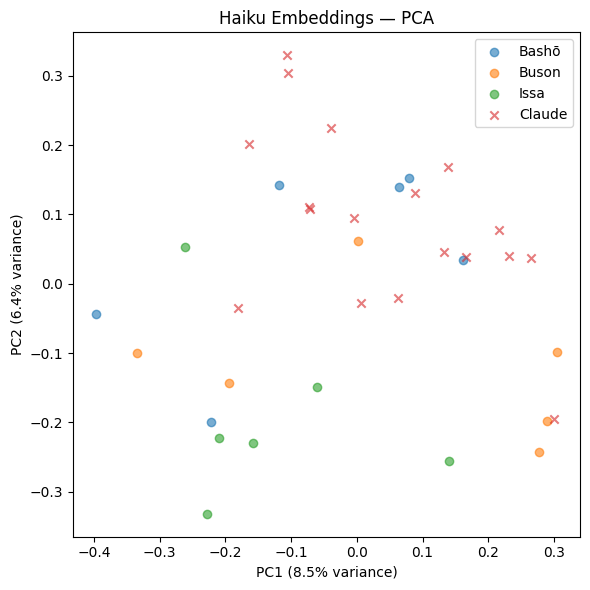

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X = np.array(embeddings)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

n_basho = len(real_haikus_basho)
start_buson = n_basho
start_issa = n_basho + len(real_haikus_buson)
n_real = len(real_haikus)

plt.figure(figsize=(6, 6))
plt.scatter(X_2d[:start_buson, 0],      X_2d[:start_buson, 1],      label="Bashō", alpha=0.6)
plt.scatter(X_2d[start_buson:start_issa, 0], X_2d[start_buson:start_issa, 1], label="Buson", alpha=0.6)
plt.scatter(X_2d[start_issa:n_real, 0], X_2d[start_issa:n_real, 1], label="Issa", alpha=0.6)
plt.scatter(X_2d[n_real:, 0],           X_2d[n_real:, 1],           label="Claude", alpha=0.6, marker="x")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Haiku Embeddings — PCA")
plt.legend()
plt.tight_layout()
plt.show()

## Tools
We can also give the model some tools to use - these are essentially just functions that we can call, and the role of the LLM is to generate the arguments to that function.

Here is a simple example to do some maths.

In [104]:
system_prompt = "You are a helpful mathematician. You will only solve the problems given to you. Do not provide any additional information. Provide only the answer. If needed, give 5 decimal places of precision. Never give a fraction."
user_query = "What is 1056514 / 1316394?"

response = client.chat.completions.create(
  model="Qwen/Qwen3.8-27B-FP8",
  messages=[
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_query},
  ],
)

print(response.choices[0].message.content)



0.80258


In [105]:
1056514 / 1316394

0.8025819017710503

In [106]:
console.print(response.choices[0].message.reasoning_content)

We need answer user's math: What is 1056514 / 1316394? Need provide only answer, decimal
precision 5 places if needed, never fraction. Need compute quotient. Let's calculate 
accurately.

We need 1056514 / 1316394. Let's compute. Both even? divide by 2: 528257 / 658197. Need 
decimal. Let's perform high precision.

Compute 1056514 / 1316394 ≈ 0.802... because 1,316,394*0.8=1,053,115.2, difference 
3,398.8, over 1,316,394 ≈0.002582. total 0.802582.

Let's compute more precisely. Let numerator N=1056514, D=1316394.
We can compute using long division or use ratio.

D * 0.8025 = D*(8025/10000) = 1316394*8025 /10000. 1,316,394*8000=10,531,152,000; 
*25=32,909,850; sum=10,564,061,850 /10000=1,056,406.185. Difference N - =107.815. 
Additional /D ≈0.000081899. So 0.802581899.

Check 0.802582: D*0.802582 = D*(802582/1e6). 1,316,394*802,582? Let's compute. 
1,316,394*802,000 = 1,316,394*802 *1000. 1,316,394*802 = 1,316,394*800 + *2 = 
1,053,115,200 + 2,632,788 = 1,055,747,988; *1000=1,055,747,988,000. *582 = 
1,316,394*500=658,197,000; *80=105,311,520; *2=2,632,788; sum=766,141,308. Total for 
802,582 =1,056,514,129,308 /1e6 =1,056,514.129308. This is 0.129308 above N. So true 
=0.802582 - 0.129308/D ≈0.802582 -0.00000009823 =0.80258190177. So to 5 decimal places: 
0.80258? Need rounding to 5 decimals. Digits: 0.8025819. Fifth decimal? Let's list 
decimals: 0 . 8 0 2 5 8 1 9. 1st=8,2nd=0,3rd=2,4th=5,5th=8,6th=1. So to 5 decimals 
0.80258 (since 6th digit 1 <5). If needed 5 decimal places precision; can output 
0.80258.

But let's verify maybe 0.802582? The prompt: "If needed, give 5 decimal places of 
precision. Never give a fraction." It says only answer. We can give 0.80258. Need ensure
no extra. Let's maybe compute exact to 5 decimals. Could also provide more? It says if 
needed, give 5 decimal places; likely answer decimal with 5 places. I'll output 0.80258.

Double-check: Could quotient be simplified? 528257/658197. Need decimal. Let's compute 
using exact long division to confirm rounding.

N=1,056,514. D=1,316,394.
0.
N*10=10,565,140; /D=8 (8*1,316,394=10,531,152), rem=33,988.
Next: 339,880 /D=0, rem=339,880.
Next: 3,398,800 /D=2 (2,632,788), rem=766,012.
Next: 7,660,120 /D=5 (6,581,970), rem=1,078,150.
Next: 10,781,500 /D=8 (10,531,152), rem=250,348.
Next: 2,503,480 /D=1 (1,316,394), rem=1,187,086.
So decimals: 8 0 2 5 8 1... yes 0.802581. 6th digit 1 so 5-decimal 0.80258. Good.

Need final only answer. Ensure no fraction. final: 0.80258.

The LLM may even be correct! (When we were running this workshop ~1 year ago, it was not)

To endow the model with "tool use", we add a function:

In [107]:
def divide(a: float, b: float) -> float:
    return a / b

And then provide the model with a _schema_, which is just a description of the function in dictionary form (or JSON):

In [108]:
tool_schema = {
    "type": "function",
    "function": {
        "name": "divide",
        "description": "Given two floats, a and b, return a divided by b.",
        "parameters": {
            "type": "object",
            "properties": {
                "a": {
                    "type": "number",
                    "description": "The divident."
                },
                "b": {
                    "type": "number",
                    "description": "The divisor."
                }
            },
            "required": ["a", "b"],
            "additionalProperties": False,
        }
    }
}

tools = [
    tool_schema
]

When we make function calls with an LLM, we have to let it know that it has access to one or more tools. We do this by passing in the `tools` argument.

In [109]:
response = client.chat.completions.create(
    model="Qwen/Qwen3.8-27B-FP8",
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_query},
    ],
    temperature=1.0,
    top_p=0.95,
    presence_penalty=1.5,
    extra_body={
        "top_k": 20,
        "chat_template_kwargs": {"enable_thinking": False},
    }, 
    tools=tools,
)

In [110]:
print(response.choices[0].message.tool_calls[0])

ChatCompletionMessageFunctionToolCall(id='chatcmpl-tool-a957f7456130158e', function=Function(arguments='{"a": 1056514, "b": 1316394}', name='divide'), type='function')


So now in our `response`, we have this extra part called `tool_calls` that we can extract information from - in this case the arguments to the `divide` function.

Note that you could achieve a similar result with appropriate prompting - e.g. "Extract only the arguments to a function that multiplies two numbers."

We unpack the actual arguments as a dictionary:

In [111]:
import json

tool_call = response.choices[0].message.tool_calls[0]
arguments = json.loads(tool_call.function.arguments)
print(arguments)

{'a': 1056514, 'b': 1316394}


And we now feed the arguments into our `divide` function:

In [112]:
result = divide(**arguments)
print(result)

0.8025819017710503


So now we have the answer. We can either just return this, or we can feed it back into the LLM. We need to provide the model with the `tool_calls[0].id`, so that it can associate response messages of the tool type with the correct tool call.

In [113]:
tool_call = response.choices[0].message.tool_calls[0]

tool_call_id = tool_call.id
tool_name = tool_call.function.name
arguments = json.loads(tool_call.function.arguments)

In [114]:
tool_response = response

tool_call = tool_response.choices[0].message.tool_calls[0]

tool_call_result = {
    "role": "tool",
    "tool_call_id": tool_call.id,
    "content": json.dumps({
        "a": arguments["a"],
        "b": arguments["b"],
        "result": result,
    }),
}

final_response = client.chat.completions.create(
    model="Qwen/Qwen3.8-27B-FP8",
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_query},
        tool_response.choices[0].message,
        tool_call_result,
    ],
    max_tokens=100,
    extra_body={
        "top_k": 20,
        "chat_template_kwargs": {
            "enable_thinking": False
        },
    },
)

final_response.choices[0].message.content

'0.80258'

This is quite a lot of work to divide two numbers, but of course the power comes when doing more complex tasks.

And this brings to light an interesting contrast. People talk a lot about "agents" and "tools" and "systems", and when we interact with ChatGPT, we get a single coherent experience. Sometimes it is difficult to distinguish between what the LLM is doing, and what the software engineers have built around it in order to create this seemless experience.

### Model-specific parameters

Different models support different optional parameters in addition to the standard chat completion arguments.

- `Qwen/Qwen3.8-27B-FP8`
  - `temperature`
  - `top_p`
  - `max_tokens`
  - `enable_thinking`
  - When served through vLLM, `enable_thinking` may need to be passed through `chat_template_kwargs`.

- `Qwen/Qwen3.6-35B`
  - `temperature`
  - `top_p`
  - `max_tokens`
  - `enable_thinking`
  - When served through vLLM, `enable_thinking` may need to be passed through `chat_template_kwargs`.

- `moonshotai/Kimi-K3`
  - `temperature`
  - `max_tokens`
  - `reasoning_effort`
    - `"low"`
    - `"high"`
    - `"max"`
  - `tools`
  - `tool_choice`
  - Returns reasoning separately as `reasoning_content`.

- `zai-org/GLM-5.3`
  - `temperature`
  - `max_tokens`
  - `reasoning_effort`
    - `"low"`
    - `"high"`
    - `"max"`
  - `clear_thinking`

- `zai-org/GLM-OCR`
  - OCR-specific image/document input parameters.
  - This is not intended to be used as a normal conversational model.

- `Qwen/Qwen3-Embedding-4B`
  - Embedding dimension
  - Input text
  - Task/instruction text
  - Does not support reasoning parameters.

- `openai/Tongyi-MAI/Z-Image-Turbo`
  - Image size / resolution
  - Number of inference steps
  - Guidance scale
  - Other image-generation parameters

- `openai/Qwen/Qwen-Image-Edit-2511`
  - `image`
  - `prompt`
  - `negative_prompt`
  - `true_cfg_scale`
  - `guidance_scale`
  - `num_inference_steps`
  - `num_images_per_prompt`
  - Seed / generator settings

The exact parameters accepted by an API request depend on both the underlying model and how that model is configured in LiteLLM/vLLM.